Facial Expression Prediction

Dataset:
- https://www.kaggle.com/datasets/msambare/fer2013/data

In [72]:
import torch
import torchvision
from torch.utils.data import ConcatDataset, DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import copy
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [73]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [74]:
import kagglehub
from pathlib import Path

path = kagglehub.dataset_download("msambare/fer2013")

print("Path to dataset files:", path)
print("isi source:", os.listdir(path))

Using Colab cache for faster access to the 'fer2013' dataset.
Path to dataset files: /kaggle/input/fer2013
isi source: ['test', 'train']


Helper Download Data

In [75]:
from pathlib import Path
import kagglehub
import shutil

from torchvision import datasets, transforms
from torch.utils.data import DataLoader


def create_dataloader(
    root: str,
    transform_train: transforms.Compose,
    transform_test: transforms.Compose,
    batch_size: int,
    num_workers: int = 4,
):
    source_path = Path(kagglehub.dataset_download("msambare/fer2013"))
    destination_path = Path(root) / "fer2013"

    # Copy dataset sekali saja
    if not destination_path.exists():
        shutil.copytree(source_path, destination_path)

    train_dataset = datasets.ImageFolder(
        root=destination_path / "train",
        transform=transform_train
    )

    test_dataset = datasets.ImageFolder(
        root=destination_path / "test",
        transform=transform_test
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

    class_names = train_dataset.classes

    print("Classes:", class_names)
    print(f"Train: {len(train_dataset)}")
    print(f"Test : {len(test_dataset)}")

    return (
        train_loader,
        test_loader,
        train_dataset,
        test_dataset,
        class_names
    )

Helper Training

In [76]:
import torch
import torchvision
from timeit import default_timer as timer
from tqdm.auto import tqdm
from typing import Dict, List, Tuple
from pathlib import Path
from PIL import Image, ImageOps


def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device) -> Tuple[float, float]:

  model.train()

  train_loss, train_acc = 0, 0

  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)

    y_pred = model(X)

    loss = loss_fn(y_pred, y)
    train_loss += loss.item()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    y_pred_class = torch.argmax(y_pred, dim=1)
    train_acc += (y_pred_class == y).sum().item() / len(y_pred)

  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)

  return train_loss, train_acc


def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.dataloader,
              loss_fn: torch.nn.Module,
              device: torch.device) -> Tuple[float, float]:

  model.eval()

  test_loss, test_acc = 0,0

  with torch.inference_mode():
    for batch, (X, y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device)

      test_pred_logits = model(X)

      loss = loss_fn(test_pred_logits, y)
      test_loss += loss.item()

      test_pred_labels = test_pred_logits.argmax(dim=1)
      test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))

    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)

    return test_loss, test_acc

class EarlyStopping:

    def __init__(self, patience=3):

        self.patience = patience
        self.counter = 0
        self.best_loss = float("inf")
        self.best_weights = None

    def __call__(self, model, val_loss):

        stop = False

        if val_loss < self.best_loss:

            self.best_loss = val_loss
            self.counter = 0
            self.best_weights = copy.deepcopy(model.state_dict())

        else:

            self.counter += 1

            if self.counter >= self.patience:
                stop = True

        return stop


def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          loss_fn: torch.nn.Module,
          optimizer: torch.optim.Optimizer,
          epochs: int,
          device: torch.device) -> Dict[str, List]:

  early_stopping = EarlyStopping(patience=3)

  best_acc = 0
  best_weights = None

  results = {"train_loss": [],
             "train_acc": [],
             "test_loss": [],
             "test_acc": []}

  train_start_time = timer()

  for epoch in tqdm(range(epochs)):
    train_loss, train_acc = train_step(model=model,
                                       dataloader=train_dataloader,
                                       loss_fn=loss_fn,
                                       optimizer=optimizer,
                                       device=device)

    test_loss, test_acc = test_step(model=model,
                                    dataloader=test_dataloader,
                                    loss_fn=loss_fn,
                                    device=device)

    scheduler.step(test_loss)

    if test_acc > best_acc:
      best_acc = test_acc
      best_weights = copy.deepcopy(model.state_dict())

      torch.save(
          model.state_dict(),
          "models/facial_expression_model_efficientnet_b0_trained_experiments.pth"
      )

    if early_stopping(model, test_loss):
      print("Early Stopping!")
      break

    print(f"epoch : {epoch + 1} | train_loss : {train_loss:.4f} | train_acc : {train_acc:.4f} | test_loss : {test_loss:.4f} | test_acc : {test_acc:.4f}\n")

    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  if best_weights is not None:
    model.load_state_dict(best_weights)

  train_end_time = timer()

  print(f"Waktu Yang Dibutuhkan Training : {train_end_time - train_start_time:.3f} seconds")

  return results

def predict(model, image_path, device, transform=None):
    if device is None:
        device = next(model.parameters()).device

    image = Image.open(image_path).convert("RGB")

    if transform is not None:
        image = transform(image)

    image = image.unsqueeze(0).to(device)
    model.to(device)
    model.eval()

    with torch.inference_mode():
        logits = model(image)
        probs = torch.softmax(logits, dim=1)

    pred = probs.argmax(dim=1).item()
    prob = probs.max().item()
    return pred, prob

Helper Save

In [77]:
import torch
from pathlib import Path


def save_checkpoint(
    model: torch.nn.Module,
    model_path: str | Path,
    class_names: list[str],
):
    model_path = Path(model_path)
    model_path.parent.mkdir(parents=True, exist_ok=True)

    checkpoint = {
        "model_state_dict": model.state_dict(),
        "class_names": class_names,
    }

    torch.save(checkpoint, model_path)

    print(f"[INFO] Checkpoint saved to: {model_path}")

Transforms

In [78]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5078, 0.5078, 0.5078],
        std=[0.2528, 0.2528, 0.2528]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5078, 0.5078, 0.5078],
        std=[0.2528, 0.2528, 0.2528]
    )
])

In [79]:
train_loader, test_loader, data_train, data_test, class_names = create_dataloader(
    root="data",
    transform_train=train_transform,
    transform_test=test_transform,
    batch_size=32,
    num_workers=2
)

Using Colab cache for faster access to the 'fer2013' dataset.
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Train: 28709
Test : 7178


In [80]:
class_names = data_train.classes
class_names

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

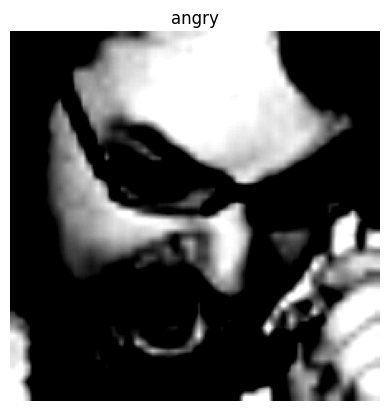

In [81]:
img, label = data_test[0]

plt.imshow(img.permute(1, 2, 0))
plt.title(class_names[label])
plt.axis(False)
plt.show()

In [82]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

dataset = datasets.ImageFolder(
    root="data/fer2013/train",
    transform=transforms.ToTensor()
)

loader = DataLoader(dataset, batch_size=64, shuffle=False)

mean = 0.
std = 0.

for images, _ in loader:
    mean += images.mean(dim=[0, 2, 3])
    std += images.std(dim=[0, 2, 3])

mean /= len(loader)
std /= len(loader)

print(mean)
print(std)

tensor([0.5078, 0.5078, 0.5078])
tensor([0.2528, 0.2528, 0.2528])


In [83]:
def test_accuracy(model, dataset, device):
    loader = DataLoader(
        dataset,
        batch_size=32,
        shuffle=False
    )

    model.eval()

    correct = 0
    total = 0

    with torch.inference_mode():
        for image, label in loader:
            image = image.to(device)
            label = label.to(device)

            logits = model(image)
            pred = logits.argmax(dim=1)

            correct += (pred == label).sum().item()
            total += label.size(0)

    return correct / total

In [84]:
weights = EfficientNet_B0_Weights.DEFAULT
model = efficientnet_b0(weights=weights)

model.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(in_features=model.classifier[1].in_features,
                    out_features=len(class_names))
)

model = model.to(device)

model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

Check Before Training Accuracy

In [85]:
model_acc = test_accuracy(
    model,
    data_test,
    device
)

print(f"Data Accuracy Before: {model_acc:.2%}")

Data Accuracy Before: 12.22%


In [86]:
for param in model.features.parameters():
    param.requires_grad = False

loss_fn = torch.nn.CrossEntropyLoss(
    label_smoothing=0.1
)

optimizer = torch.optim.Adam(
    model.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=2
)

Check Accuracy Small Datasets

In [87]:
X, y = next(iter(train_loader))

X = X.to(device)

model.eval()

with torch.no_grad():
    out = model(X)

print(out.shape)
print(out[0])

torch.Size([32, 7])
tensor([ 0.4603, -0.0716, -0.2288, -0.0191, -0.3867, -0.2051,  0.6671],
       device='cuda:0')


In [88]:
train_indices = torch.randperm(len(data_train))[:100]
test_indices = torch.randperm(len(data_test))[:100]

train_subset = Subset(data_train, train_indices)
test_subset = Subset(data_test, test_indices)

len(train_subset), len(test_subset)

(100, 100)

In [89]:
train_subset_loader = DataLoader(
    train_subset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
)

test_subset_loader = DataLoader(
    test_subset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
)

len(train_subset), len(test_subset)

(100, 100)

In [90]:
results = train(
    model=model,
    train_dataloader=train_subset_loader,
    test_dataloader=test_subset_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    epochs=20,
    device=device
)

  0%|          | 0/20 [00:00<?, ?it/s]

epoch : 1 | train_loss : 1.9078 | train_acc : 0.2578 | test_loss : 1.8878 | test_acc : 0.1641

epoch : 2 | train_loss : 1.8284 | train_acc : 0.2266 | test_loss : 1.8650 | test_acc : 0.1953

epoch : 3 | train_loss : 1.6972 | train_acc : 0.3047 | test_loss : 1.8451 | test_acc : 0.1953

epoch : 4 | train_loss : 1.8310 | train_acc : 0.3359 | test_loss : 1.8346 | test_acc : 0.1484

epoch : 5 | train_loss : 1.6637 | train_acc : 0.3828 | test_loss : 1.8256 | test_acc : 0.1797

epoch : 6 | train_loss : 1.6629 | train_acc : 0.4062 | test_loss : 1.8312 | test_acc : 0.2109

epoch : 7 | train_loss : 1.5930 | train_acc : 0.5078 | test_loss : 1.8287 | test_acc : 0.2422

epoch : 8 | train_loss : 1.6005 | train_acc : 0.4531 | test_loss : 1.8244 | test_acc : 0.2812

epoch : 9 | train_loss : 1.5587 | train_acc : 0.3828 | test_loss : 1.8206 | test_acc : 0.2734

epoch : 10 | train_loss : 1.5511 | train_acc : 0.4531 | test_loss : 1.8126 | test_acc : 0.3438

epoch : 11 | train_loss : 1.6037 | train_acc : 0.

Train Large Datasets

In [91]:
for param in model.features.parameters():
    param.requires_grad = False

loss_fn = torch.nn.CrossEntropyLoss(
    label_smoothing=0.1
)

optimizer = torch.optim.Adam(
    model.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=2
)

results_stage1 = train(
    model=model,
    train_dataloader=train_loader,
    test_dataloader=test_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    epochs=3,          # classifier yang dilatih
    device=device
)

  0%|          | 0/3 [00:00<?, ?it/s]

epoch : 1 | train_loss : 1.6637 | train_acc : 0.3833 | test_loss : 1.6401 | test_acc : 0.4041

epoch : 2 | train_loss : 1.6207 | train_acc : 0.4103 | test_loss : 1.6019 | test_acc : 0.4199

epoch : 3 | train_loss : 1.6192 | train_acc : 0.4114 | test_loss : 1.5735 | test_acc : 0.4342

Waktu Yang Dibutuhkan Training : 266.633 seconds


In [92]:
for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=2
)

results_stage2 = train(
    model=model,
    train_dataloader=train_loader,
    test_dataloader=test_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    epochs=10,
    device=device
)

  0%|          | 0/10 [00:00<?, ?it/s]

epoch : 1 | train_loss : 1.3696 | train_acc : 0.5464 | test_loss : 1.2451 | test_acc : 0.6154

epoch : 2 | train_loss : 1.1920 | train_acc : 0.6395 | test_loss : 1.1778 | test_acc : 0.6497

epoch : 3 | train_loss : 1.1056 | train_acc : 0.6883 | test_loss : 1.1597 | test_acc : 0.6626

epoch : 4 | train_loss : 1.0342 | train_acc : 0.7243 | test_loss : 1.1346 | test_acc : 0.6783

epoch : 5 | train_loss : 0.9655 | train_acc : 0.7592 | test_loss : 1.1351 | test_acc : 0.6844

epoch : 6 | train_loss : 0.8997 | train_acc : 0.7952 | test_loss : 1.1461 | test_acc : 0.6935

Early Stopping!
Waktu Yang Dibutuhkan Training : 1204.212 seconds


In [93]:
correct = 0
total = 0

model.eval()

with torch.inference_mode():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print(f"Correct : {correct}")
print(f"Total   : {total}")
print(f"Acc     : {correct/total:.4f}")

Correct : 4977
Total   : 7178
Acc     : 0.6934


Result 1

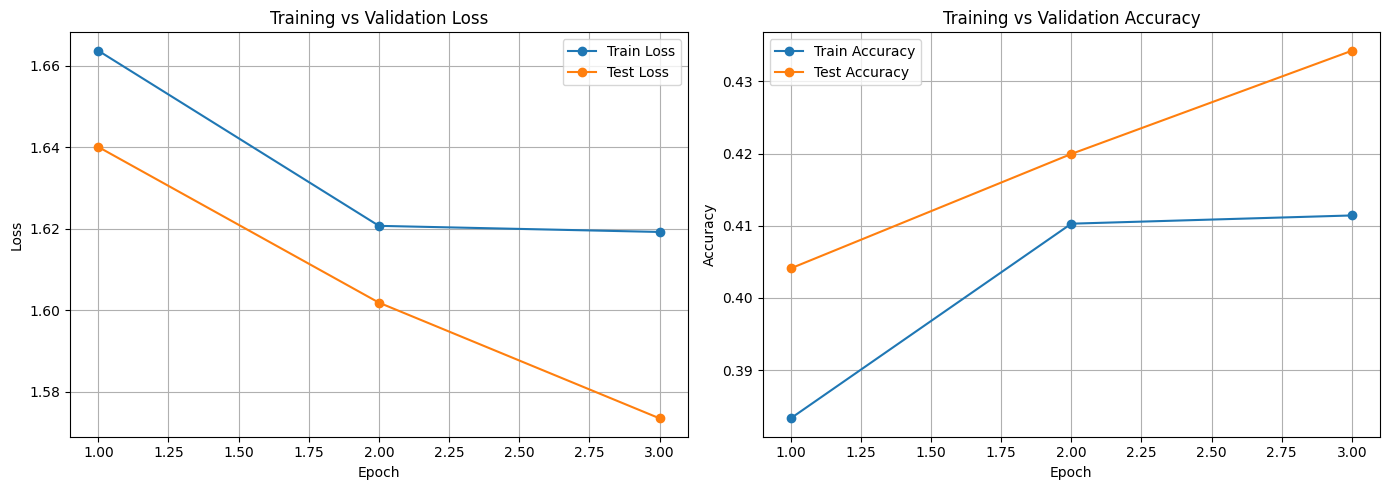

In [94]:
import matplotlib.pyplot as plt

train_loss = results_stage1["train_loss"]
test_loss = results_stage1["test_loss"]
train_acc = results_stage1["train_acc"]
test_acc = results_stage1["test_acc"]

epochs = range(1, len(train_loss) + 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax[0].plot(epochs, train_loss, label="Train Loss", marker="o")
ax[0].plot(epochs, test_loss, label="Test Loss", marker="o")
ax[0].set_title("Training vs Validation Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()
ax[0].grid(True)

# Accuracy
ax[1].plot(epochs, train_acc, label="Train Accuracy", marker="o")
ax[1].plot(epochs, test_acc, label="Test Accuracy", marker="o")
ax[1].set_title("Training vs Validation Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

Result 2

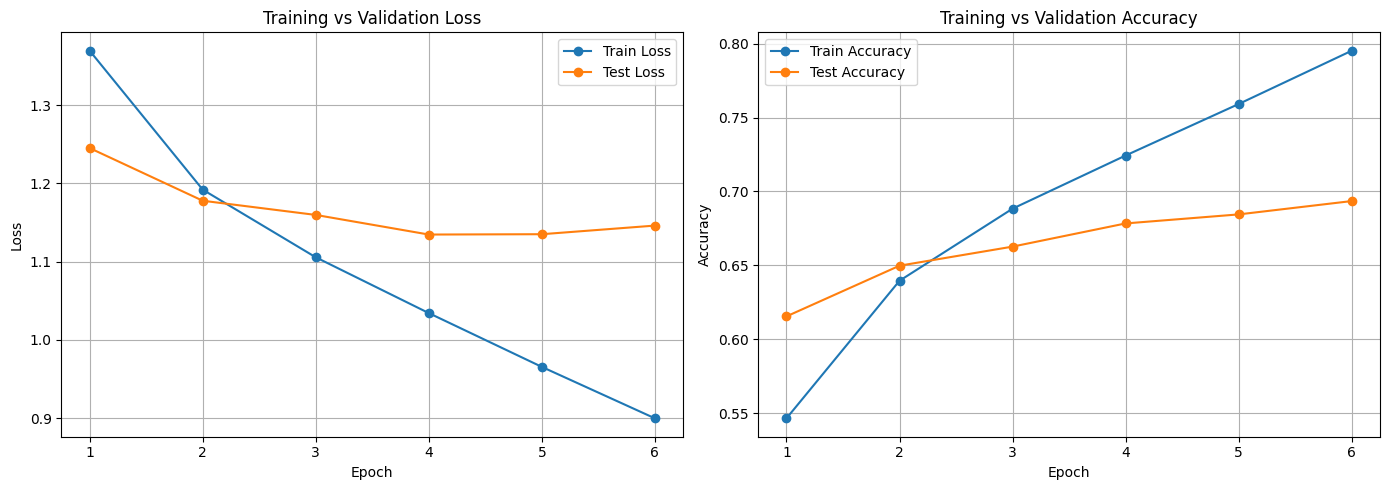

In [95]:
import matplotlib.pyplot as plt

train_loss = results_stage2["train_loss"]
test_loss = results_stage2["test_loss"]
train_acc = results_stage2["train_acc"]
test_acc = results_stage2["test_acc"]

epochs = range(1, len(train_loss) + 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax[0].plot(epochs, train_loss, label="Train Loss", marker="o")
ax[0].plot(epochs, test_loss, label="Test Loss", marker="o")
ax[0].set_title("Training vs Validation Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()
ax[0].grid(True)

# Accuracy
ax[1].plot(epochs, train_acc, label="Train Accuracy", marker="o")
ax[1].plot(epochs, test_acc, label="Test Accuracy", marker="o")
ax[1].set_title("Training vs Validation Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

Accuracy After Train

In [96]:
model_acc = test_accuracy(
    model,
    data_test,
    device
)

print(f"Data Accuracy After Training : {model_acc:.2%}")

Data Accuracy After Training : 69.34%


Lets Prediction

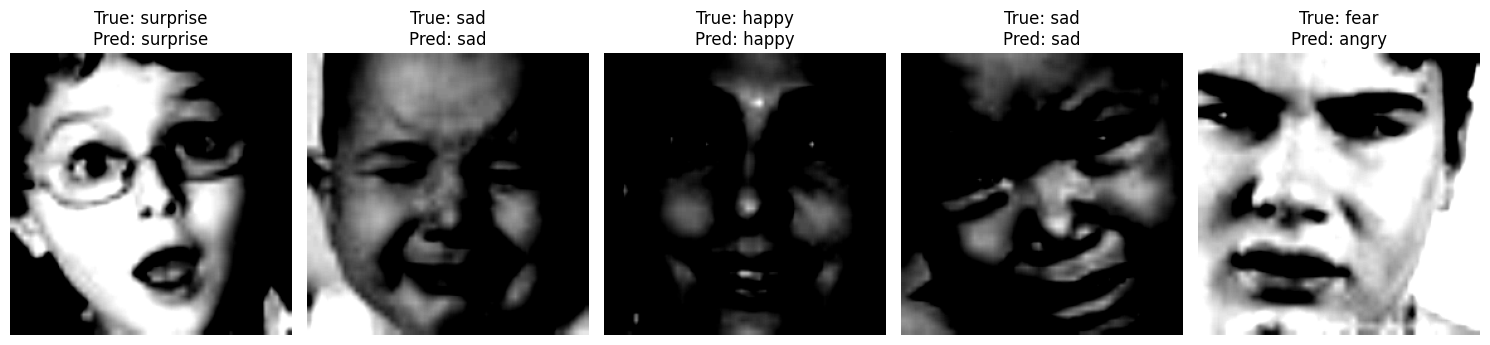

In [97]:
import random

random_indices = random.sample(range(len(data_test)), 5)

fig, axes = plt.subplots(1, 5, figsize=(15, 4))
model.eval()

for i, idx in enumerate(random_indices):
    img, true_label = data_test[idx]

    with torch.inference_mode():
        logits = model(img.unsqueeze(0).to(device))
        pred_label = logits.argmax(dim=1).item()

    axes[i].imshow(img.permute(1, 2, 0))
    axes[i].set_title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

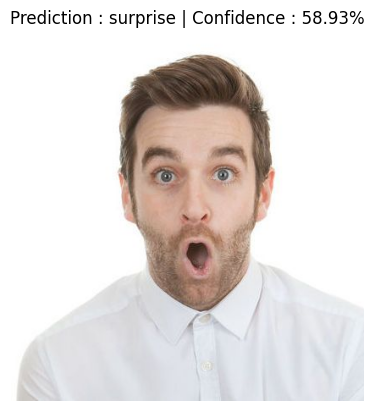

In [98]:
from PIL import Image

path_data = Path("data/")
image_path = path_data / "prediction_image/predict_image.jpg"

image = Image.open(image_path)

transforms_pred = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5078, 0.5078, 0.5078],
        std=[0.2528, 0.2528, 0.2528]
    )
])

pred, prob = predict(
    model=model,
    image_path=image_path,
    device=device,
    transform=transforms_pred,
)

plt.imshow(image)
plt.title(f"Prediction : {class_names[pred]} | Confidence : {prob:.2%}")
plt.axis("off")
plt.show()